In [1]:
!pip install transformers

In [25]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm, trange
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU Available: True
GPU Name: Tesla T4


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# Configuration
config = {
    'model_name': 'bert-base-uncased',  # Pretrained BERT model
    'data_dir': '/content/drive/MyDrive/ABSA-BERT-pair2/data/semeval2014/bert-pair/',
    'train_file': 'train_NLI_M.csv',
    'test_file': 'test_NLI_M.csv',
    'max_seq_length': 128,
    'batch_size': 16,
    'learning_rate': 5e-5,
    'num_epochs': 1,
    'warmup_ratio': 0.1,
    'weight_decay': 0.01,
    'seed': 42,
    'output_dir': '/content/drive/MyDrive/new/Out_Test',
}

# Label mapping
LABEL2ID = {
    'positive': 0,
    'neutral': 1,
    'negative': 2,
    'conflict': 3,
    'none': 4
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

# Set seeds
np.random.seed(config['seed'])
torch.manual_seed(config['seed'])
torch.cuda.manual_seed_all(config['seed'])

print("Configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")

Configuration:
  model_name: bert-base-uncased
  data_dir: /content/drive/MyDrive/ABSA-BERT-pair2/data/semeval2014/bert-pair/
  train_file: train_NLI_M.csv
  test_file: test_NLI_M.csv
  max_seq_length: 128
  batch_size: 16
  learning_rate: 5e-05
  num_epochs: 1
  warmup_ratio: 0.1
  weight_decay: 0.01
  seed: 42
  output_dir: /content/drive/MyDrive/new/Out_Test


In [28]:
# Load training data
train_path = os.path.join(config['data_dir'], config['train_file'])
test_path = os.path.join(config['data_dir'], config['test_file'])

# Read data: ID, sentiment, aspect, text
train_df = pd.read_csv(train_path, sep='\t', header=None,
                        names=['id', 'sentiment', 'aspect', 'text'])
test_df = pd.read_csv(test_path, sep='\t', header=None,
                       names=['id', 'sentiment', 'aspect', 'text'])

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print("\nFirst 5 rows of training data:")
print(train_df.head())
print("\nLabel distribution:")
print(train_df['sentiment'].value_counts())
print("\nSample data:")
for idx in range(3):
    print(f"\nSample {idx+1}:")
    print(f"  Text: {train_df.iloc[idx]['text'][:80]}...")
    print(f"  Aspect: {train_df.iloc[idx]['aspect']}")
    print(f"  Sentiment: {train_df.iloc[idx]['sentiment']}")

Training data shape: (15220, 4)
Test data shape: (4000, 4)

First 5 rows of training data:
     id sentiment     aspect                                  text
0  3121      none      price  But the staff was so horrible to us.
1  3121      none  anecdotes  But the staff was so horrible to us.
2  3121      none       food  But the staff was so horrible to us.
3  3121      none   ambience  But the staff was so horrible to us.
4  3121  negative    service  But the staff was so horrible to us.

Label distribution:
sentiment
none        11508
positive     2176
negative      839
neutral       501
conflict      196
Name: count, dtype: int64

Sample data:

Sample 1:
  Text: But the staff was so horrible to us....
  Aspect: price
  Sentiment: none

Sample 2:
  Text: But the staff was so horrible to us....
  Aspect: anecdotes
  Sentiment: none

Sample 3:
  Text: But the staff was so horrible to us....
  Aspect: food
  Sentiment: none


In [29]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(config['model_name'])

def preprocess_data(df, tokenizer, max_length=128):
    """
    Preprocess data: tokenize text and aspect, convert labels to IDs
    text_a: aspect, text_b: review text, label: sentiment
    """
    input_ids_list = []
    attention_mask_list = []
    token_type_ids_list = []
    labels_list = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Tokenizing"):
        aspect = row['aspect']
        text = row['text']
        sentiment = row['sentiment']

        # Tokenize with aspect as text_a and review as text_b
        encodings = tokenizer(
            aspect,  # text_a (aspect)
            text,    # text_b (review)
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True,
            return_tensors='pt'
        )

        input_ids_list.append(encodings['input_ids'].squeeze())
        attention_mask_list.append(encodings['attention_mask'].squeeze())
        token_type_ids_list.append(encodings['token_type_ids'].squeeze())
        labels_list.append(LABEL2ID.get(sentiment, LABEL2ID['none']))

    return {
        'input_ids': torch.stack(input_ids_list),
        'attention_mask': torch.stack(attention_mask_list),
        'token_type_ids': torch.stack(token_type_ids_list),
        'labels': torch.tensor(labels_list)
    }

# Preprocess training data
print("Preprocessing training data...")
train_encodings = preprocess_data(train_df, tokenizer, config['max_seq_length'])
print(f"Training data shape: {train_encodings['input_ids'].shape}")
print(f"Sample input_ids: {train_encodings['input_ids'][0][:20]}")
print(f"Sample attention_mask: {train_encodings['attention_mask'][0][:20]}")
print(f"Sample label: {train_encodings['labels'][0]} ({ID2LABEL[train_encodings['labels'][0].item()]})")

# Preprocess test data
print("\nPreprocessing test data...")
test_encodings = preprocess_data(test_df, tokenizer, config['max_seq_length'])
print(f"Test data shape: {test_encodings['input_ids'].shape}")

Preprocessing training data...


Tokenizing: 100%|██████████| 15220/15220 [00:10<00:00, 1492.87it/s]


Training data shape: torch.Size([15220, 128])
Sample input_ids: tensor([ 101, 3976,  102, 2021, 1996, 3095, 2001, 2061, 9202, 2000, 2149, 1012,
         102,    0,    0,    0,    0,    0,    0,    0])
Sample attention_mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0])
Sample label: 4 (none)

Preprocessing test data...


Tokenizing: 100%|██████████| 4000/4000 [00:02<00:00, 1831.10it/s]

Test data shape: torch.Size([4000, 128])


In [30]:
# Create datasets and dataloaders
train_dataset = TensorDataset(
    train_encodings['input_ids'],
    train_encodings['attention_mask'],
    train_encodings['token_type_ids'],
    train_encodings['labels']
)

test_dataset = TensorDataset(
    test_encodings['input_ids'],
    test_encodings['attention_mask'],
    test_encodings['token_type_ids'],
    test_encodings['labels']
)

# DataLoaders
train_sampler = RandomSampler(train_dataset)
train_dataloader = DataLoader(
    train_dataset,
    sampler=train_sampler,
    batch_size=config['batch_size']
)

test_sampler = SequentialSampler(test_dataset)
test_dataloader = DataLoader(
    test_dataset,
    sampler=test_sampler,
    batch_size=config['batch_size']
)

print(f"Number of training batches: {len(train_dataloader)}")
print(f"Number of test batches: {len(test_dataloader)}")

# Check a batch
batch = next(iter(train_dataloader))
print(f"\nBatch shapes:")
print(f"  input_ids: {batch[0].shape}")
print(f"  attention_mask: {batch[1].shape}")
print(f"  token_type_ids: {batch[2].shape}")
print(f"  labels: {batch[3].shape}")

Number of training batches: 952
Number of test batches: 250

Batch shapes:
  input_ids: torch.Size([16, 128])
  attention_mask: torch.Size([16, 128])
  token_type_ids: torch.Size([16, 128])
  labels: torch.Size([16])


In [31]:
# Load pretrained BERT model for sequence classification
num_labels = len(LABEL2ID)
model = AutoModelForSequenceClassification.from_pretrained(
    config['model_name'],
    num_labels=num_labels,
    output_hidden_states=False
)

# Move model to device
model.to(device)

print(f"Model loaded: {config['model_name']}")
print(f"Number of labels: {num_labels}")
print(f"Model device: {next(model.parameters()).device}")
print(f"\nModel architecture:")
print(model)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: bert-base-uncased
Number of labels: 5
Model device: cuda:0

Model architecture:
BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_feat

In [32]:
# Calculate total training steps and warmup steps
total_steps = len(train_dataloader) * config['num_epochs']
warmup_steps = int(total_steps * config['warmup_ratio'])

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

# Optimizer setup with weight decay (similar to their BERTAdam approach)
# Split parameters: no weight decay for bias, gamma, beta
no_decay = ['bias', 'gamma', 'beta', 'LayerNorm.bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {
        'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        'weight_decay': config['weight_decay'],
    },
    {
        'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0,
    },
]

# Use AdamW optimizer (modern replacement for BERTAdam)
from torch.optim import AdamW
optimizer = AdamW(optimizer_grouped_parameters, lr=config['learning_rate'])

# Learning rate scheduler with warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\nOptimizer: AdamW")
print(f"Learning rate: {config['learning_rate']}")
print(f"Weight decay: {config['weight_decay']}")
print(f"Warmup steps: {warmup_steps}")

Total training steps: 952
Warmup steps: 95

Optimizer: AdamW
Learning rate: 5e-05
Weight decay: 0.01
Warmup steps: 95


In [33]:
# Create output directory
os.makedirs(config['output_dir'], exist_ok=True)

# Training loop
def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    for batch_idx, batch in enumerate(progress_bar):
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        token_type_ids = batch[2].to(device)
        labels = batch[3].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass
        loss.backward()

        # Clip gradients (optional, for stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update weights
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        progress_bar.update(1)
        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(dataloader)
    return avg_loss

# Training
print("Starting training...")
training_losses = []

for epoch in trange(config['num_epochs'], desc="Epoch"):
    print(f"\nEpoch {epoch + 1}/{config['num_epochs']}")
    avg_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)
    training_losses.append(avg_loss)
    print(f"Average training loss: {avg_loss:.4f}")

print("\nTraining completed!")
print(f"Training losses: {[f'{loss:.4f}' for loss in training_losses]}")

Starting training...


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch 1/1



Training: 100%|██████████| 952/952 [05:52<00:00,  2.69it/s, loss=0.344]
Training: 953it [05:52,  2.67it/s, loss=0.344]                         
Training: 953it [05:52,  2.67it/s, loss=0.69] 
Training: 954it [05:52,  2.61it/s, loss=0.69]
Training: 954it [05:53,  2.61it/s, loss=0.0575]
Training: 955it [05:53,  2.65it/s, loss=0.0575]
Training: 955it [05:53,  2.65it/s, loss=0.334] 
Training: 956it [05:53,  2.63it/s, loss=0.334]
Training: 956it [05:53,  2.63it/s, loss=0.142]
Training: 957it [05:53,  2.60it/s, loss=0.142]
Training: 957it [05:54,  2.60it/s, loss=0.0228]
Training: 958it [05:54,  2.61it/s, loss=0.0228]
Training: 958it [05:54,  2.61it/s, loss=0.56]  
Training: 959it [05:54,  2.63it/s, loss=0.56]
Training: 959it [05:54,  2.63it/s, loss=0.105]
Training: 960it [05:55,  2.59it/s, loss=0.105]
Training: 960it [05:55,  2.59it/s, loss=0.204]
Training: 961it [05:55,  2.65it/s, loss=0.204]
Training: 961it [05:55,  2.65it/s, loss=0.464]
Training: 962it [05:55,  2.63it/s, loss=0.464]
Train

Average training loss: 0.5141

Training completed!
Training losses: ['0.5141']


In [36]:
# Evaluation function
def evaluate(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_logits = []

    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc="Evaluating", leave=False)
        for batch in progress_bar:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            token_type_ids = batch[2].to(device)
            labels = batch[3].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )

            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_logits.extend(logits.cpu().detach().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_logits)

# Evaluate on test set
print("Evaluating on test set...")
test_preds, test_labels, test_logits = evaluate(model, test_dataloader, device)

# Calculate metrics
accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
recall = recall_score(test_labels, test_preds, average='weighted', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='weighted', zero_division=0)

print(f"\nTest Results:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Confusion matrix
print(f"\nConfusion Matrix:")
cm = confusion_matrix(test_labels, test_preds)
print(cm)

# Per-class metrics
print(f"\nPer-class results:")
for label_id, label_name in ID2LABEL.items():
    mask = test_labels == label_id
    if mask.sum() > 0:
        class_acc = (test_preds[mask] == test_labels[mask]).mean()
        print(f"  {label_name}: {class_acc:.4f} (samples: {mask.sum()})")

Evaluating on test set...



Test Results:
  Accuracy:  0.9127
  Precision: 0.9034
  Recall:    0.9127
  F1-Score:  0.9048

Confusion Matrix:
[[ 544    6   25    2   80]
 [  25   32   16    0   21]
 [  17    1  146    5   53]
 [  20    1   15    4   12]
 [  32    3   15    0 2925]]

Per-class results:
  positive: 0.8280 (samples: 657)
  neutral: 0.3404 (samples: 94)
  negative: 0.6577 (samples: 222)
  conflict: 0.0769 (samples: 52)
  none: 0.9832 (samples: 2975)


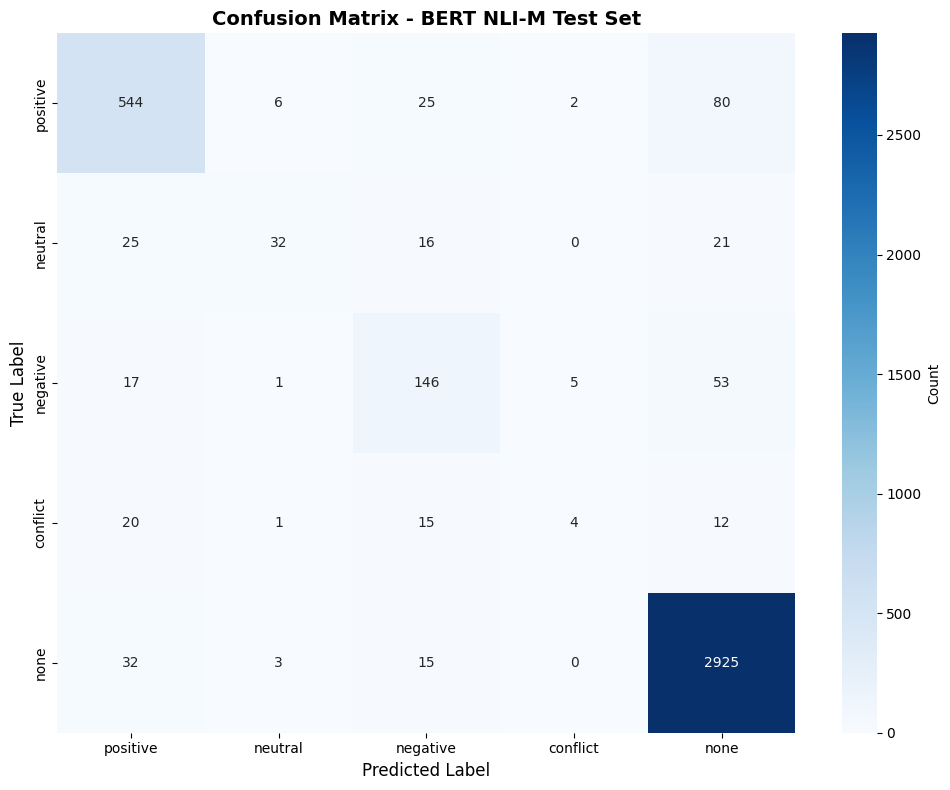


✅ Confusion matrix saved to: /content/drive/MyDrive/new/Out_Test/confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix visualization
plt.figure(figsize=(10, 8))

# Create confusion matrix
cm = confusion_matrix(test_labels, test_preds, labels=list(range(len(ID2LABEL))))

# Plot with seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[ID2LABEL[i] for i in range(len(ID2LABEL))],
            yticklabels=[ID2LABEL[i] for i in range(len(ID2LABEL))],
            cbar_kws={'label': 'Count'},
            vmin=0)

plt.title('Confusion Matrix - BERT NLI-M Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(config['output_dir'], 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Confusion matrix saved to: {os.path.join(config['output_dir'], 'confusion_matrix.png')}")

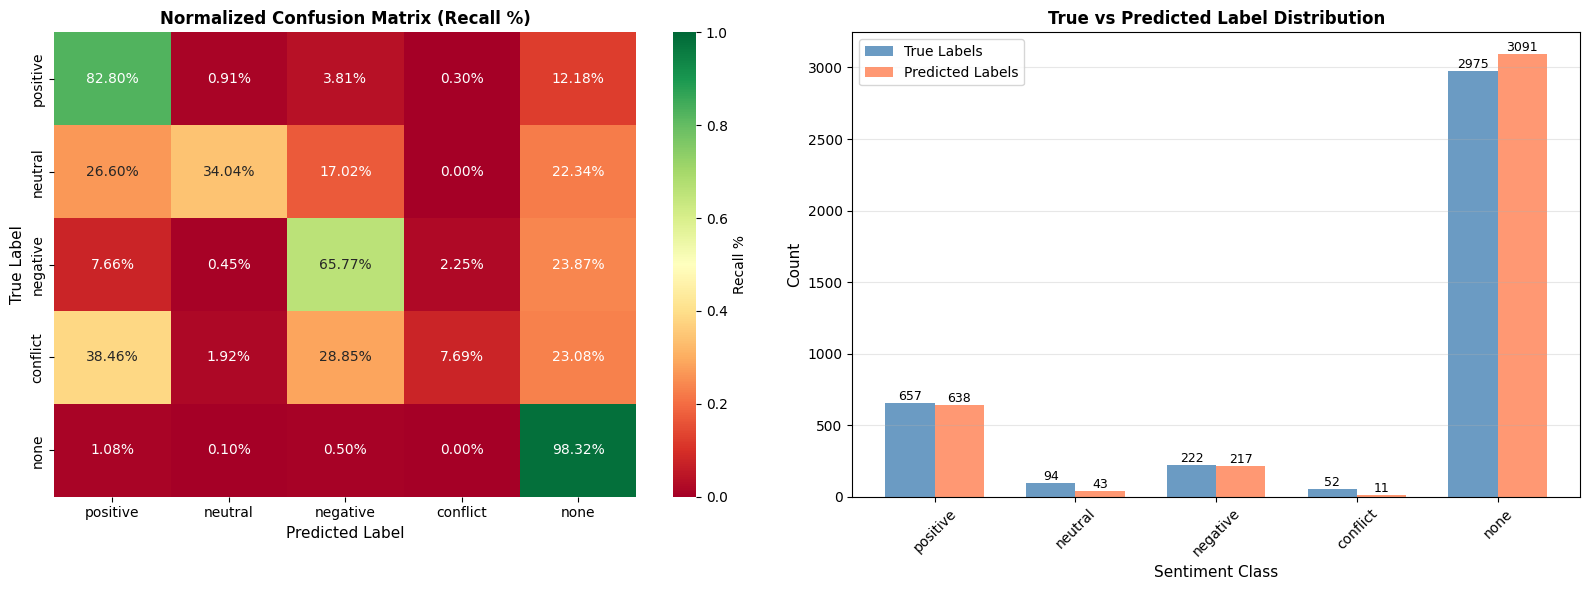


✅ Analysis plot saved to: /content/drive/MyDrive/new/Out_Test/cm_analysis.png

📊 Per-class Recall (Sensitivity):
  positive    : 82.80% (544/657)
  neutral     : 34.04% (32/94)
  negative    : 65.77% (146/222)
  conflict    : 7.69% (4/52)
  none        : 98.32% (2925/2975)


In [39]:
import numpy as np

# Create a 2x2 subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Normalized Confusion Matrix (row-wise)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[0],
            xticklabels=[ID2LABEL[i] for i in range(len(ID2LABEL))],
            yticklabels=[ID2LABEL[i] for i in range(len(ID2LABEL))],
            cbar_kws={'label': 'Recall %'},
            vmin=0, vmax=1)

axes[0].set_title('Normalized Confusion Matrix (Recall %)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# 2. Prediction Distribution
label_names = [ID2LABEL[i] for i in range(len(ID2LABEL))]
true_counts = [np.sum(test_labels == i) for i in range(len(ID2LABEL))]
pred_counts = [np.sum(test_preds == i) for i in range(len(ID2LABEL))]

x = np.arange(len(label_names))
width = 0.35

bars1 = axes[1].bar(x - width/2, true_counts, width, label='True Labels', alpha=0.8, color='steelblue')
bars2 = axes[1].bar(x + width/2, pred_counts, width, label='Predicted Labels', alpha=0.8, color='coral')

axes[1].set_xlabel('Sentiment Class', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('True vs Predicted Label Distribution', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(label_names, rotation=45)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(config['output_dir'], 'cm_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Analysis plot saved to: {os.path.join(config['output_dir'], 'cm_analysis.png')}")

# Print per-class recall
print("\n📊 Per-class Recall (Sensitivity):")
print("=" * 50)
for i, label in enumerate(label_names):
    if true_counts[i] > 0:
        recall = cm[i, i] / true_counts[i]
        print(f"  {label:12s}: {recall:.2%} ({cm[i, i]}/{true_counts[i]})")